## 🔭 Astronomical Object Detection Tool
**Repository:** DL-Simplified | **GSSoC 2026**

**Project Overview** :
This project aims to **detect and classify astronomical objects** from images
using multiple deep learning approaches.

In [1]:
# ── Install required packages ──────────────────────
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn Pillow -q
print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [3]:
# ── Upload dataset ZIP from your local device ──────
from google.colab import files
import os

print("📂 Please select your dataset ZIP file...")
uploaded = files.upload()  # select your zip file here

ZIP_NAME = list(uploaded.keys())[0]
print(f"✅ Uploaded: {ZIP_NAME}")

📂 Please select your dataset ZIP file...


Saving Astronomy Image Classification Dataset.zip to Astronomy Image Classification Dataset.zip
✅ Uploaded: Astronomy Image Classification Dataset.zip


In [4]:
# ── Unzip the uploaded dataset ─────────────────────
!unzip -q "{ZIP_NAME}" -d /content/dataset
print("✅ Dataset extracted!")

# ── Check what's inside ────────────────────────────
import os
for root, dirs, files_list in os.walk('/content/dataset'):
    level = root.replace('/content/dataset', '').count(os.sep)
    indent = '   ' * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    if level < 2:
        for f in files_list[:2]:
            print(f"{indent}   📄 {f}")

✅ Dataset extracted!
📁 dataset/
   📁 space images/
      📁 cosmos space - Google Search/
      📁 planets - Google Search/
      📁 galaxies - Google Search/
      📁 nebula - Google Search/
      📁 stars - Google Search/
      📁 constellation - Google Search/


---
## Section 1 — Imports & Configuration

In [5]:
# ── Standard Libraries ─────────────────────────────
import os, warnings, random
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

In [6]:
# ── Visualization ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
sns.set_style("darkgrid")

In [7]:
# ── Deep Learning ──────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, InceptionV3, MobileNetV2
from tensorflow.keras.optimizers import Adam

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ TensorFlow version: 2.20.0
✅ GPU Available: True


In [9]:
# ── Global Configuration ───────────────────────────
DATASET_PATH = "/content/dataset/space images"
IMG_SIZE     = (128, 128)
BATCH_SIZE   = 32
EPOCHS       = 30
SEED         = 42

CLASSES = sorted(os.listdir(DATASET_PATH))
NUM_CLASSES = len(CLASSES)

# Clean class names for display
CLASS_NAMES = [c.split(' - ')[0].strip().title() for c in CLASSES]

print("⚙️  Configuration:")
print(f"   Image Size  : {IMG_SIZE}")
print(f"   Batch Size  : {BATCH_SIZE}")
print(f"   Max Epochs  : {EPOCHS}")
print(f"   Num Classes : {NUM_CLASSES}")
print(f"   Classes     : {CLASS_NAMES}")

⚙️  Configuration:
   Image Size  : (128, 128)
   Batch Size  : 32
   Max Epochs  : 30
   Num Classes : 6
   Classes     : ['Constellation', 'Cosmos Space', 'Galaxies', 'Nebula', 'Planets', 'Stars']


---
## Section 2 — Exploratory Data Analysis (EDA)

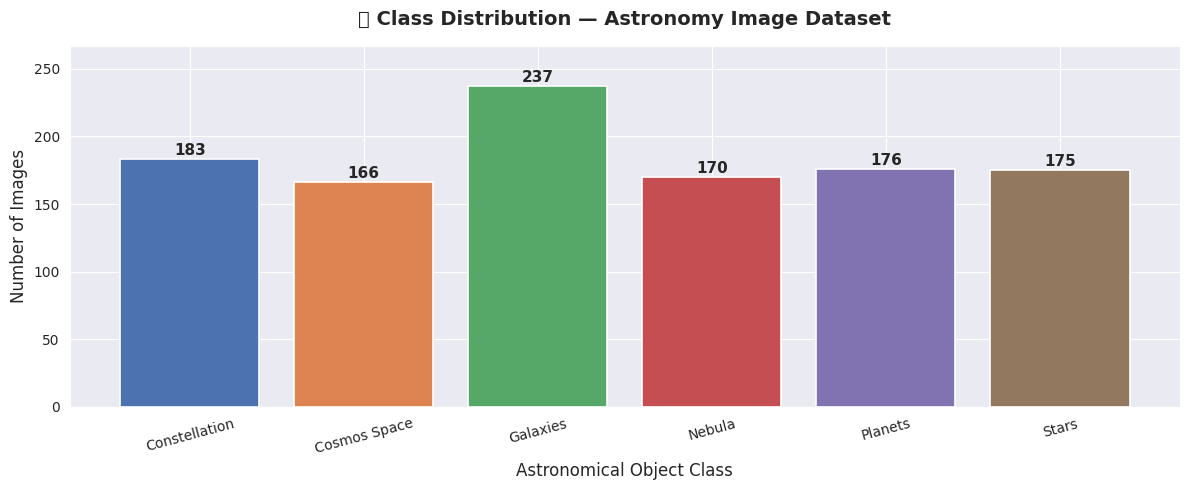

✅ Saved: class_distribution.png


In [10]:
# ── Class Distribution ─────────────────────────────
class_counts = {}
for cls, name in zip(CLASSES, CLASS_NAMES):
    class_counts[name] = len(os.listdir(os.path.join(DATASET_PATH, cls)))

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3, str(val),
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('📊 Class Distribution — Astronomy Image Dataset',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Astronomical Object Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_ylim(0, max(class_counts.values()) + 30)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: class_distribution.png")

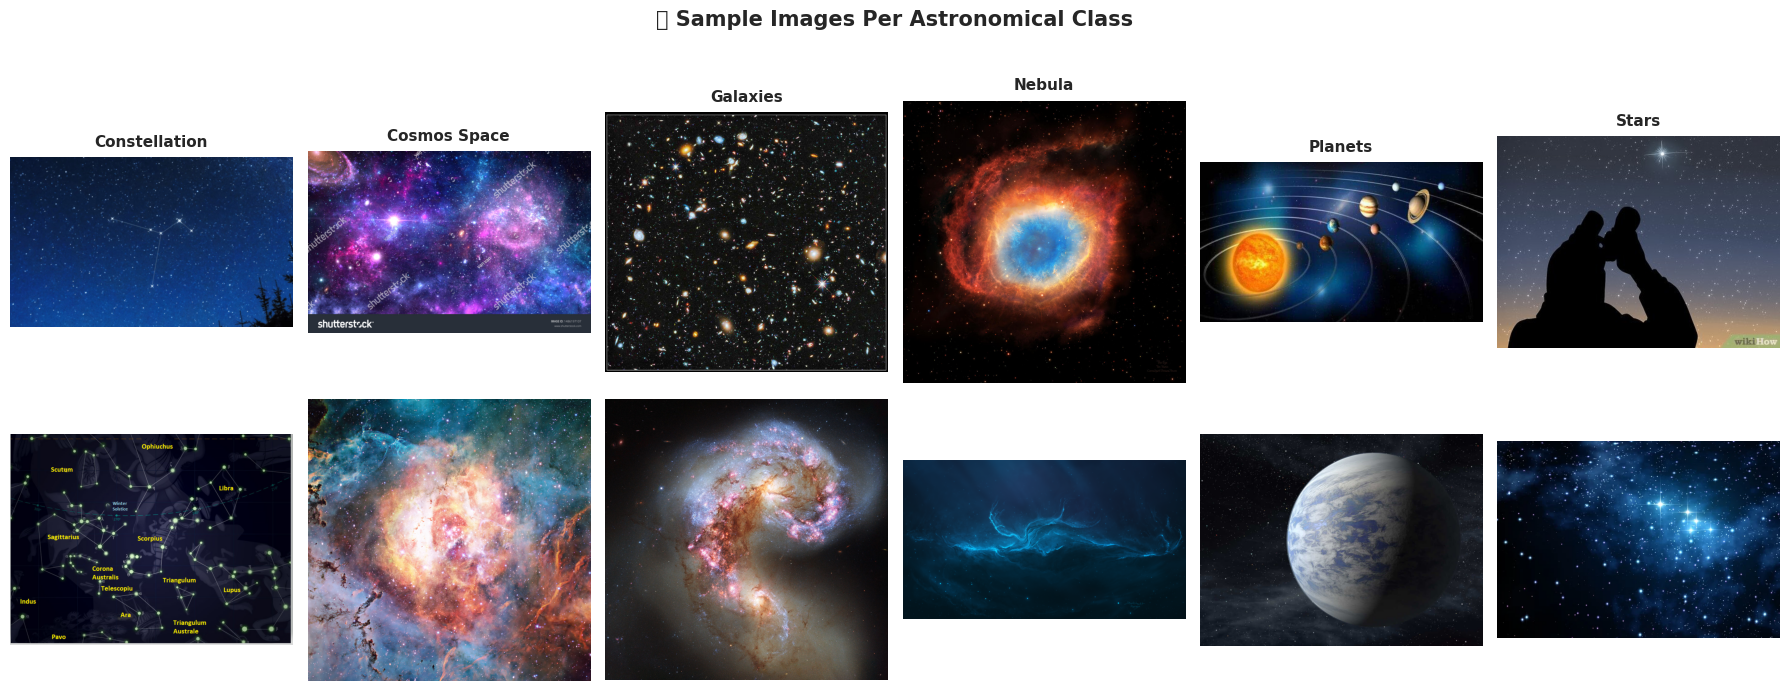

✅ Saved: sample_images.png


In [11]:
# ── Sample Images — 2 per class ────────────────────
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(18, 7))
fig.suptitle('🔭 Sample Images Per Astronomical Class',
             fontsize=15, fontweight='bold', y=1.02)

for col, (cls, name) in enumerate(zip(CLASSES, CLASS_NAMES)):
    cls_path = os.path.join(DATASET_PATH, cls)
    images   = random.sample(os.listdir(cls_path), 2)
    for row in range(2):
        img_path = os.path.join(cls_path, images[row])
        img      = mpimg.imread(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(name, fontsize=11,
                                     fontweight='bold', pad=8)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: sample_images.png")

In [12]:
# ── Image Shape Analysis ───────────────────────────
print("📐 Checking image dimensions across classes:\n")
shapes = []
for cls in CLASSES:
    cls_path = os.path.join(DATASET_PATH, cls)
    sample   = random.choice(os.listdir(cls_path))
    img      = mpimg.imread(os.path.join(cls_path, sample))
    shapes.append(img.shape)
    print(f"   {cls.split(' - ')[0]:20s} → shape: {img.shape}")

print(f"\n📌 All images will be resized to: {IMG_SIZE[0]}x{IMG_SIZE[1]}x3")

📐 Checking image dimensions across classes:

   constellation        → shape: (1176, 1600, 3)
   cosmos space         → shape: (503, 670, 3)
   galaxies             → shape: (240, 360, 3)
   nebula               → shape: (540, 960, 3)
   planets              → shape: (1200, 1200, 3)
   stars                → shape: (1200, 1200, 3)

📌 All images will be resized to: 128x128x3


---
## Section 3 — Data Preprocessing & Augmentation

In [13]:
# ── Compute Class Weights (handle imbalance) ───────
counts  = np.array(list(class_counts.values()))
weights = counts.sum() / (NUM_CLASSES * counts)
class_weight_dict = dict(enumerate(weights))

print("⚖️  Class Weights (to handle imbalance):")
for i, (name, w) in enumerate(zip(CLASS_NAMES, weights)):
    print(f"   {name:15s} → weight: {w:.4f}")

⚖️  Class Weights (to handle imbalance):
   Constellation   → weight: 1.0082
   Cosmos Space    → weight: 1.1114
   Galaxies        → weight: 0.7785
   Nebula          → weight: 1.0853
   Planets         → weight: 1.0483
   Stars           → weight: 1.0543


In [14]:
# ── Data Generators ────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=SEED, shuffle=True
)
val_gen = train_datagen.flow_from_directory(
    DATASET_PATH, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', seed=SEED, shuffle=False
)

print(f"\n✅ Training samples   : {train_gen.samples}")
print(f"✅ Validation samples : {val_gen.samples}")

Found 887 images belonging to 6 classes.
Found 220 images belonging to 6 classes.

✅ Training samples   : 887
✅ Validation samples : 220


In [15]:
# ── Helper: Plot Training History ──────────────────
def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'📈 {model_name} — Training History',
                 fontsize=13, fontweight='bold')

    ax1.plot(history.history['accuracy'],     label='Train', color='#4C72B0', lw=2)
    ax1.plot(history.history['val_accuracy'], label='Val',   color='#DD8452', lw=2)
    ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy'); ax1.set_ylim(0, 1)

    ax2.plot(history.history['loss'],     label='Train', color='#4C72B0', lw=2)
    ax2.plot(history.history['val_loss'], label='Val',   color='#DD8452', lw=2)
    ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')

    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_')
    plt.savefig(f'history_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [16]:
# ── Helper: Confusion Matrix ───────────────────────
def plot_confusion_matrix(model, generator, model_name):
    generator.reset()
    preds  = model.predict(generator, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = generator.classes

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                linewidths=0.5)
    plt.title(f'🔥 {model_name} — Confusion Matrix',
              fontsize=13, fontweight='bold', pad=12)
    plt.ylabel('True Label', fontsize=11)
    plt.xlabel('Predicted Label', fontsize=11)
    plt.xticks(rotation=30); plt.yticks(rotation=0)
    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_')
    plt.savefig(f'cm_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
    print(f"\n📋 Classification Report — {model_name}:\n")
    print(report)
    acc = np.mean(y_pred == y_true)
    return acc

print("✅ Helper functions defined!")

✅ Helper functions defined!


---
##  Model 1 — Custom 6-Layer CNN (Baseline)

> **Why?** Establishes a performance baseline. Built entirely from scratch
> using Conv2D, MaxPooling, and Dense layers with Dropout regularization.

In [17]:
tf.random.set_seed(SEED)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=6,
    restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, verbose=1
)

# ── Architecture ───────────────────────────────────
cnn = models.Sequential([
    # Block 1
    layers.Conv2D(32,(3,3), activation='relu',
                  padding='same', input_shape=(*IMG_SIZE,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64,(3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128,(3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Classifier head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='Custom_6Layer_CNN')

cnn.compile(optimizer=Adam(1e-3),
            loss='categorical_crossentropy',
            metrics=['accuracy'])
cnn.summary()

Model: "Custom_6Layer_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,550 (32.37 MB)

 Trainable params: 8,484,102 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
print("🚀 Training Custom CNN...")
hist_cnn = cnn.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

🚀 Training Custom CNN...
Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.2649 - loss: 10.3305 - val_accuracy: 0.1500 - val_loss: 8.6236 - learning_rate: 0.0010
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 26s 920ms/step - accuracy: 0.2807 - loss: 3.8958 - val_accuracy: 0.1545 - val_loss: 9.9757 - learning_rate: 0.0010
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 26s 914ms/step - accuracy: 0.2616 - loss: 1.9808 - val_accuracy: 0.1500 - val_loss: 6.9932 - learning_rate: 0.0010
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 25s 921ms/step - accuracy: 0.2785 - loss: 1.7437 - val_accuracy: 0.1864 - val_loss: 6.6437 - learning_rate: 0.0010
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 27s 981ms/step - accuracy: 0.2706 - loss: 1.6939 - val_accuracy: 0.2682 - val_loss: 4.3155 - learning_rate: 0.0010
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 27s 987ms/step - accuracy: 0.2852 - loss: 1.6758 - val_accuracy: 0.1773 - val_loss: 4.2724 - learning_rate: 0.0010
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accurac

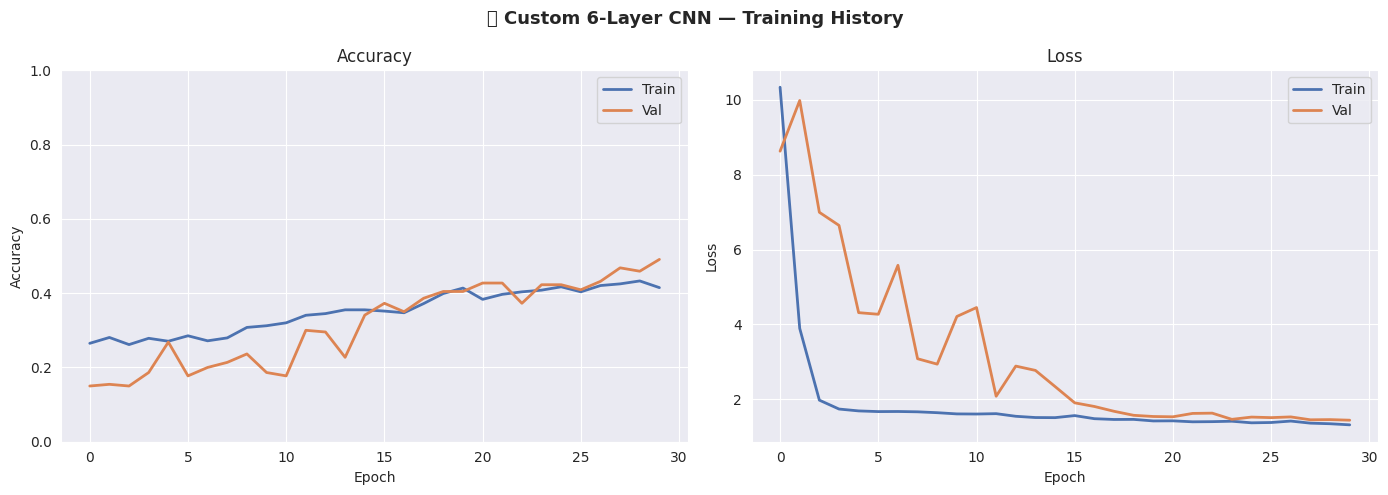

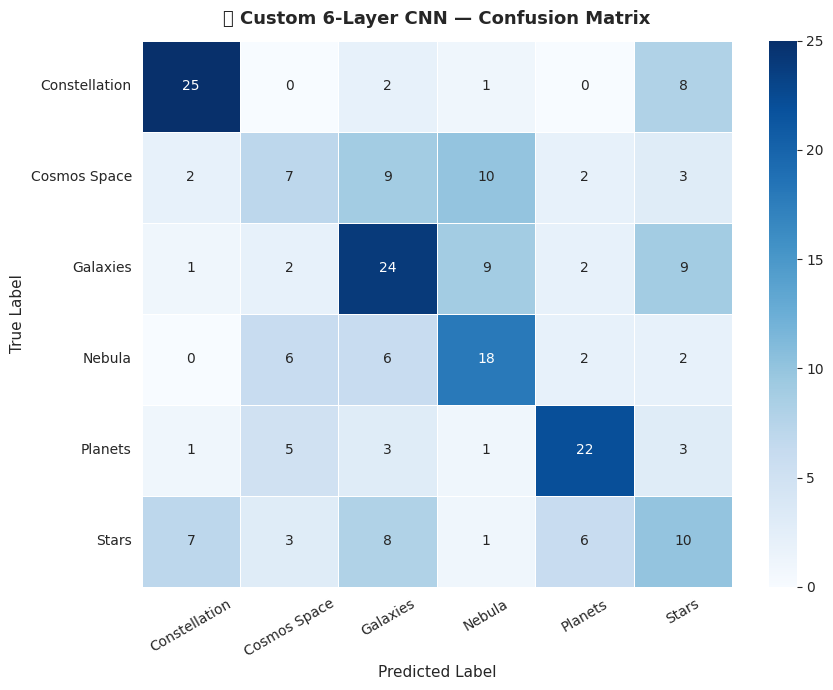


📋 Classification Report — Custom 6-Layer CNN:

               precision    recall  f1-score   support

Constellation       0.69      0.69      0.69        36
 Cosmos Space       0.30      0.21      0.25        33
     Galaxies       0.46      0.51      0.48        47
       Nebula       0.45      0.53      0.49        34
      Planets       0.65      0.63      0.64        35
        Stars       0.29      0.29      0.29        35

     accuracy                           0.48       220
    macro avg       0.47      0.48      0.47       220
 weighted avg       0.48      0.48      0.48       220


🎯 Best Validation Accuracy (CNN): 49.09%


In [19]:
plot_history(hist_cnn, 'Custom 6-Layer CNN')
acc_cnn = plot_confusion_matrix(cnn, val_gen, 'Custom 6-Layer CNN')
print(f"\n🎯 Best Validation Accuracy (CNN): {max(hist_cnn.history['val_accuracy']):.2%}")

---
##  Model 2 — ResNet50 (Transfer Learning)

> **Why?** Residual connections preserve fine-grained spatial features
> across deep layers — important for distinguishing structurally subtle
> classes like Stars vs Cosmos that may appear visually similar.

In [22]:
tf.random.set_seed(SEED)
train_gen.reset(); val_gen.reset()

base_resnet = ResNet50(weights='imagenet', include_top=False,
                       input_shape=(*IMG_SIZE,3))
base_resnet.trainable = False

resnet = models.Sequential([
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='ResNet50_Transfer')

resnet.compile(optimizer=Adam(1e-4),
               loss='categorical_crossentropy',
               metrics=['accuracy'])
resnet.summary()

print("\n🚀 Training ResNet50...")
hist_resnet = resnet.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


🚀 Training ResNet50...
Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.1770 - loss: 1.9555 - val_accuracy: 0.2409 - val_loss: 1.7987 - learning_rate: 1.0000e-04
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.1917 - loss: 1.8614 - val_accuracy: 0.2045 - val_loss: 1.7881 - learning_rate: 1.0000e-04
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.1657 - loss: 1.8529
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.1759 - loss: 1.8497 - val_accuracy: 0.2273 - val_loss: 1.7811 - learning_rate: 1.0000e-04
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.1612 - loss: 1.8672 - val_accuracy: 0.2909 - val_loss: 1.7778 - learning_rate: 5.0000e-05
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.1680 - loss: 1.8529 - val_accuracy: 0.2045 - val_loss: 1.7742 - learning_rate: 5.0000e-05
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - a

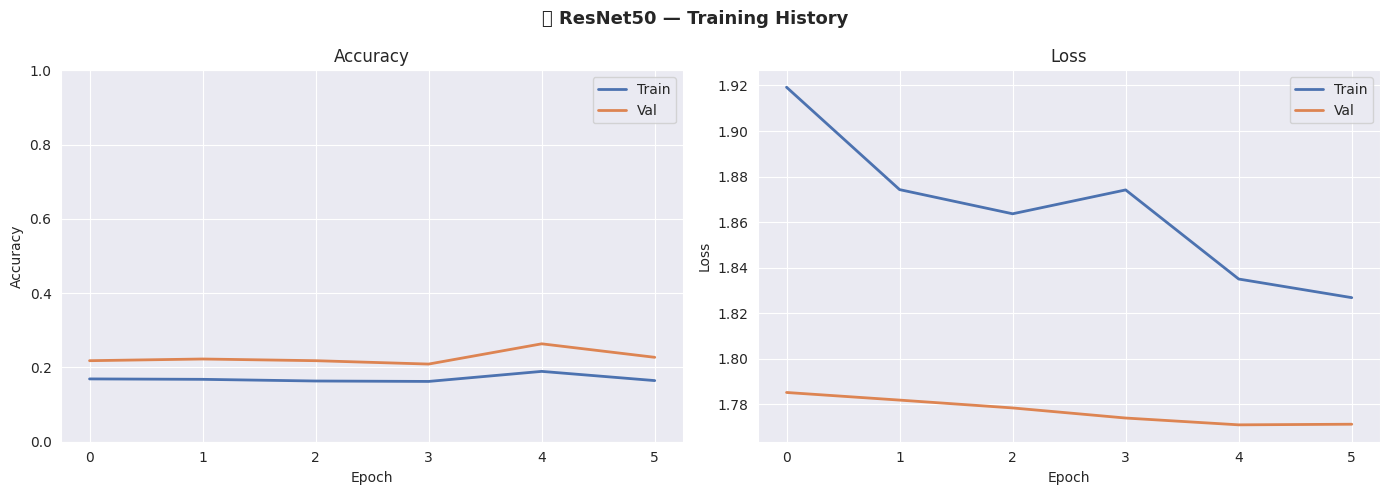

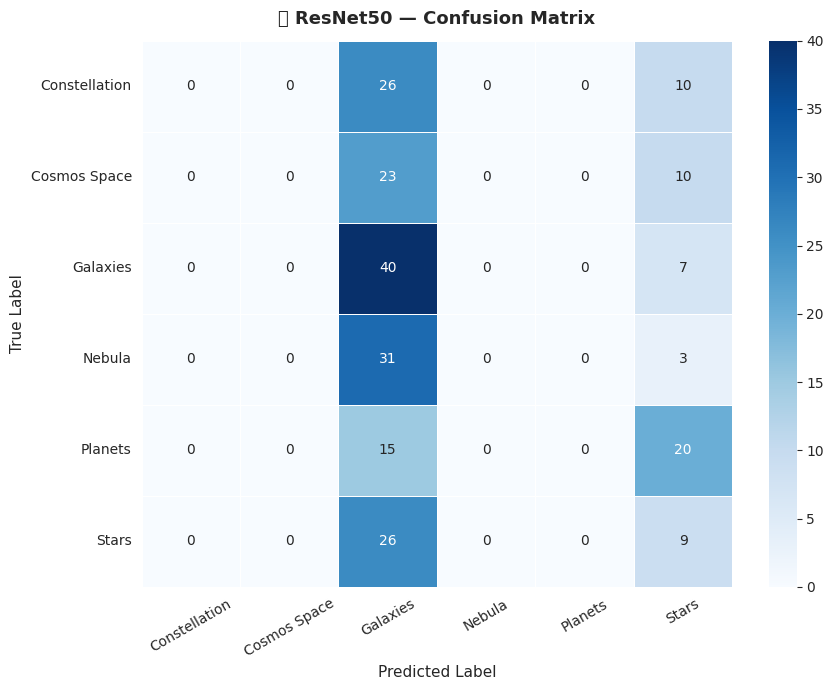


📋 Classification Report — ResNet50:

               precision    recall  f1-score   support

Constellation       0.00      0.00      0.00        36
 Cosmos Space       0.00      0.00      0.00        33
     Galaxies       0.25      0.85      0.38        47
       Nebula       0.00      0.00      0.00        34
      Planets       0.00      0.00      0.00        35
        Stars       0.15      0.26      0.19        35

     accuracy                           0.22       220
    macro avg       0.07      0.18      0.10       220
 weighted avg       0.08      0.22      0.11       220


🎯 Best Validation Accuracy (ResNet50): 26.36%


In [21]:
plot_history(hist_resnet, 'ResNet50')
acc_resnet = plot_confusion_matrix(resnet, val_gen, 'ResNet50')
print(f"\n🎯 Best Validation Accuracy (ResNet50): {max(hist_resnet.history['val_accuracy']):.2%}")

---
##  Model 3 — InceptionV3 (Transfer Learning)

> **Why?** Parallel multi-scale convolution blocks make it well-suited
> for this dataset where objects vary drastically in scale and texture —  
> from the diffuse spread of Nebulae to the compact structure of Planets.

In [23]:
# InceptionV3 needs minimum 75x75 — use 150x150
INC_SIZE = (150, 150)

train_gen_inc = train_datagen.flow_from_directory(
    DATASET_PATH, target_size=INC_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=SEED, shuffle=True
)
val_gen_inc = train_datagen.flow_from_directory(
    DATASET_PATH, target_size=INC_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', seed=SEED, shuffle=False
)

tf.random.set_seed(SEED)
base_inc = InceptionV3(weights='imagenet', include_top=False,
                       input_shape=(*INC_SIZE,3))
base_inc.trainable = False

inception = models.Sequential([
    base_inc,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='InceptionV3_Transfer')

inception.compile(optimizer=Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
inception.summary()

print("\n🚀 Training InceptionV3...")
hist_inception = inception.fit(
    train_gen_inc, epochs=EPOCHS,
    validation_data=val_gen_inc,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Found 887 images belonging to 6 classes.
Found 220 images belonging to 6 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "InceptionV3_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 3, 3, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,328,870 (85.18 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)


🚀 Training InceptionV3...
Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.2311 - loss: 2.2286 - val_accuracy: 0.3500 - val_loss: 1.5393 - learning_rate: 1.0000e-04
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.3675 - loss: 1.6618 - val_accuracy: 0.5000 - val_loss: 1.3324 - learning_rate: 1.0000e-04
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.4532 - loss: 1.4608 - val_accuracy: 0.5091 - val_loss: 1.3081 - learning_rate: 1.0000e-04
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.4848 - loss: 1.3948 - val_accuracy: 0.5273 - val_loss: 1.3105 - learning_rate: 1.0000e-04
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5321 - loss: 1.3074 - val_accuracy: 0.5773 - val_loss: 1.2609 - learning_rate: 1.0000e-04
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5186 - loss: 1.2434 - val_accuracy: 0.5273 - val_loss: 1.2334 - learning_rate: 1.0000e-04
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step

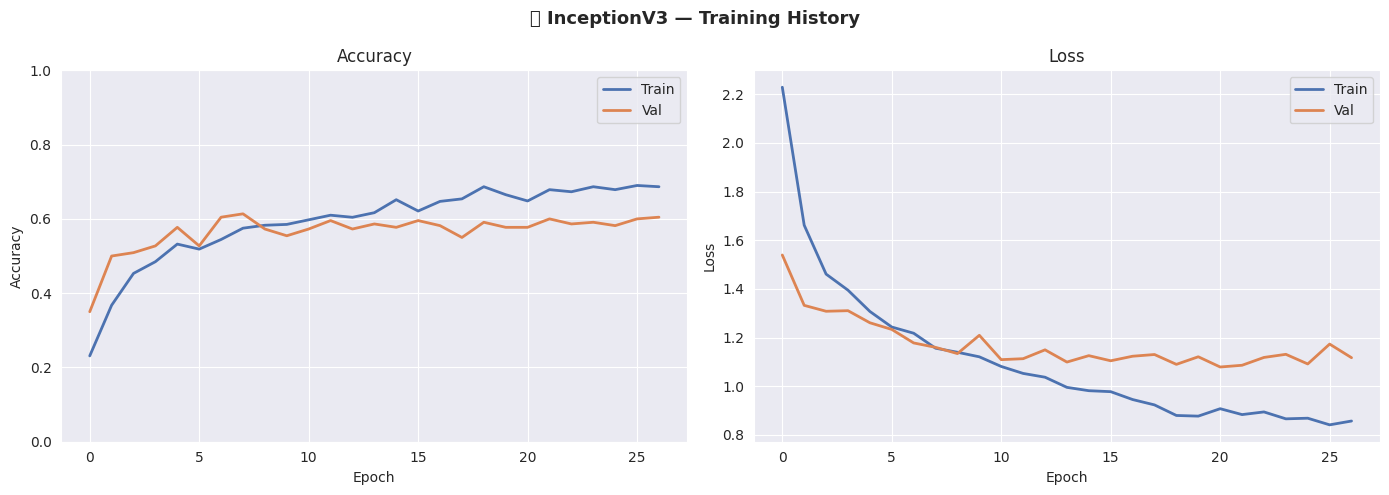

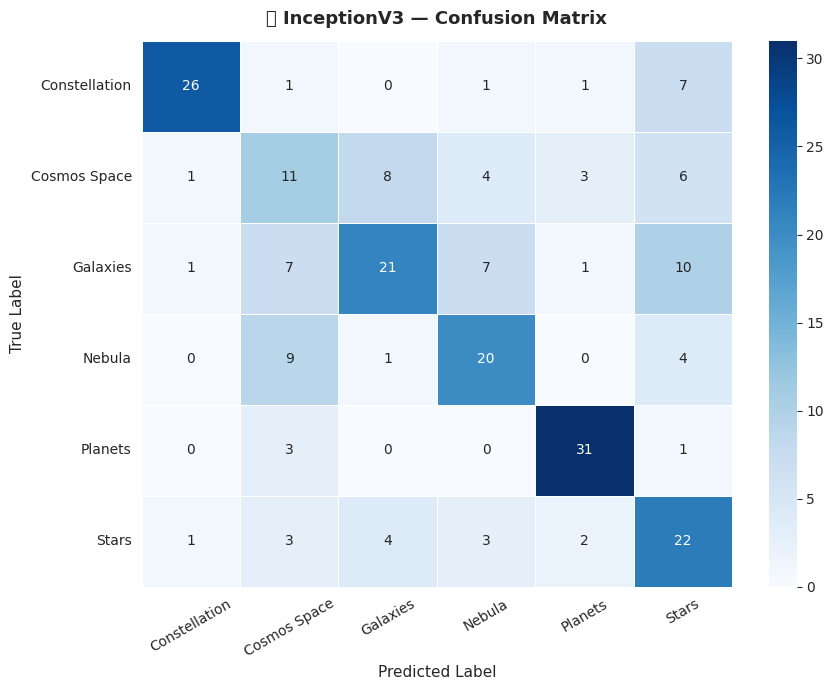


📋 Classification Report — InceptionV3:

               precision    recall  f1-score   support

Constellation       0.90      0.72      0.80        36
 Cosmos Space       0.32      0.33      0.33        33
     Galaxies       0.62      0.45      0.52        47
       Nebula       0.57      0.59      0.58        34
      Planets       0.82      0.89      0.85        35
        Stars       0.44      0.63      0.52        35

     accuracy                           0.60       220
    macro avg       0.61      0.60      0.60       220
 weighted avg       0.62      0.60      0.60       220


🎯 Best Val Accuracy (InceptionV3): 61.36%


In [24]:
plot_history(hist_inception, 'InceptionV3')
acc_inception = plot_confusion_matrix(inception, val_gen_inc, 'InceptionV3')
print(f"\n🎯 Best Val Accuracy (InceptionV3): {max(hist_inception.history['val_accuracy']):.2%}")

---
##  Model 4 — MobileNetV2 (Lightweight Transfer Learning)

> **Why?** A computationally efficient model added to evaluate the
> accuracy-efficiency tradeoff and assess whether a lighter model can
> still reliably differentiate these visually distinct classes.

In [25]:
tf.random.set_seed(SEED)
train_gen.reset(); val_gen.reset()

base_mob = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(*IMG_SIZE,3))
base_mob.trainable = False

mobilenet = models.Sequential([
    base_mob,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='MobileNetV2_Transfer')

mobilenet.compile(optimizer=Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
mobilenet.summary()

print("\n🚀 Training MobileNetV2...")
hist_mobilenet = mobilenet.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


🚀 Training MobileNetV2...
Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.1905 - loss: 2.2606 - val_accuracy: 0.2636 - val_loss: 1.6906 - learning_rate: 1.0000e-04
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.2954 - loss: 1.8336 - val_accuracy: 0.3591 - val_loss: 1.4777 - learning_rate: 1.0000e-04
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.3580 - loss: 1.6090
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
28/28 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.4002 - loss: 1.5393 - val_accuracy: 0.4273 - val_loss: 1.3913 - learning_rate: 1.0000e-04
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 27s 958ms/step - accuracy: 0.4284 - loss: 1.4394 - val_accuracy: 0.4727 - val_loss: 1.3164 - learning_rate: 5.0000e-05
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 27s 976ms/step - accuracy: 0.4487 - loss: 1.3829 - val_accuracy: 0.5000 - val_loss: 1.2753 - learning_rate: 5.0000e-05
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms

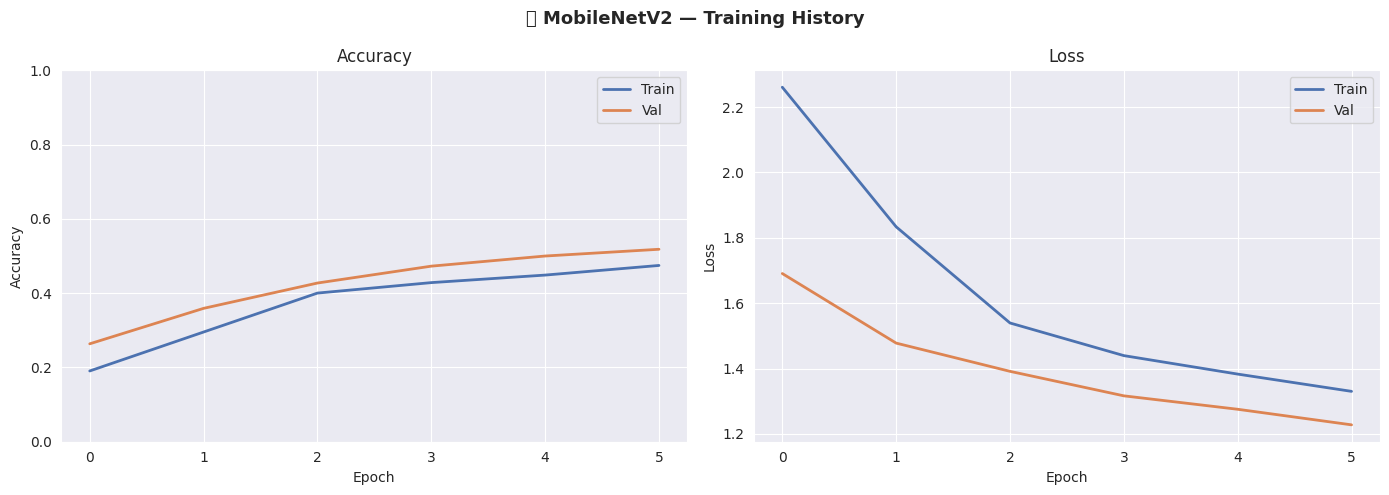

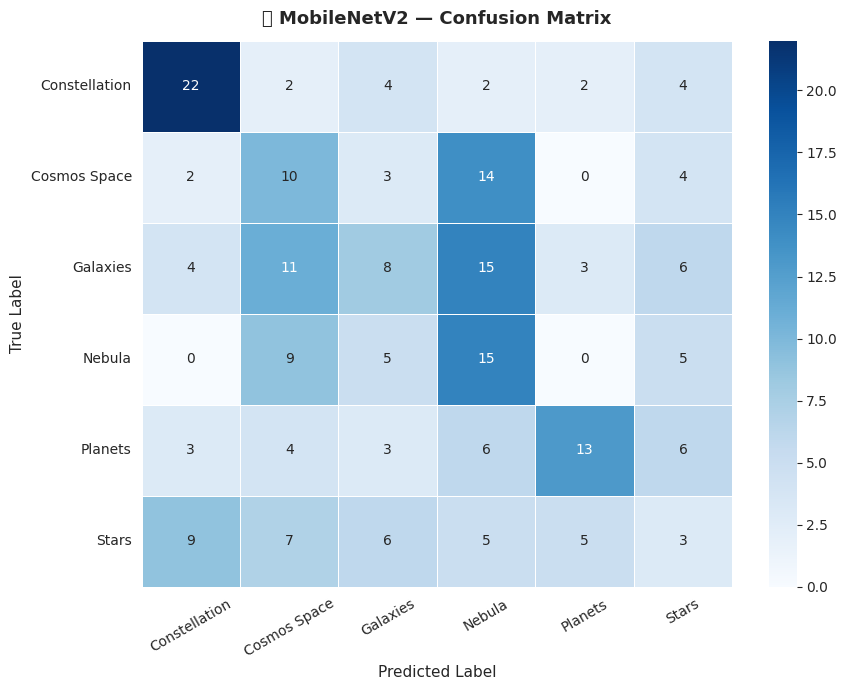


📋 Classification Report — MobileNetV2:

               precision    recall  f1-score   support

Constellation       0.55      0.61      0.58        36
 Cosmos Space       0.23      0.30      0.26        33
     Galaxies       0.28      0.17      0.21        47
       Nebula       0.26      0.44      0.33        34
      Planets       0.57      0.37      0.45        35
        Stars       0.11      0.09      0.10        35

     accuracy                           0.32       220
    macro avg       0.33      0.33      0.32       220
 weighted avg       0.33      0.32      0.32       220


🎯 Best Val Accuracy (MobileNetV2): 51.82%


In [26]:
plot_history(hist_mobilenet, 'MobileNetV2')
acc_mobilenet = plot_confusion_matrix(mobilenet, val_gen, 'MobileNetV2')
print(f"\n🎯 Best Val Accuracy (MobileNetV2): {max(hist_mobilenet.history['val_accuracy']):.2%}")

---
##  Section 4 — Model Comparison & Final Results

        📋 MODEL COMPARISON SUMMARY
      Model Train Acc Val Acc
 Custom CNN    43.29%  49.09%
   ResNet50    19.17%  31.82%
InceptionV3    69.00%  61.36%
MobileNetV2    47.46%  51.82%

🏆 Best Model: InceptionV3 (61.36% val accuracy)


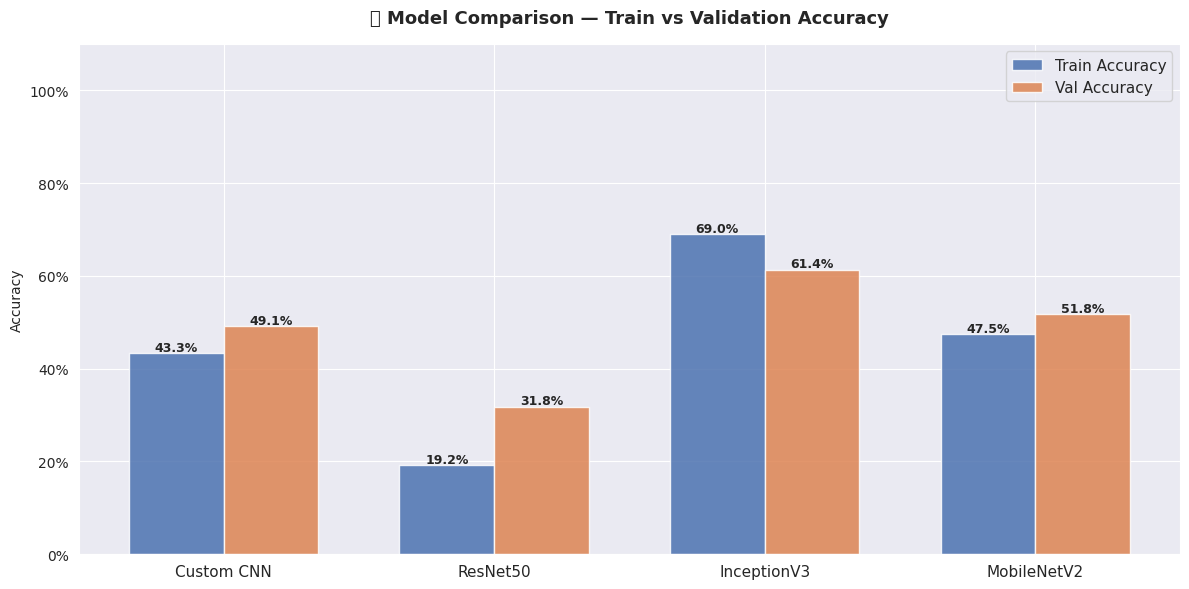

✅ Saved: model_comparison.png


In [27]:
# ── Results Summary ────────────────────────────────
model_names = ['Custom CNN', 'ResNet50', 'InceptionV3', 'MobileNetV2']
val_accs = [
    max(hist_cnn.history['val_accuracy']),
    max(hist_resnet.history['val_accuracy']),
    max(hist_inception.history['val_accuracy']),
    max(hist_mobilenet.history['val_accuracy'])
]
train_accs = [
    max(hist_cnn.history['accuracy']),
    max(hist_resnet.history['accuracy']),
    max(hist_inception.history['accuracy']),
    max(hist_mobilenet.history['accuracy'])
]

# ── Summary Table ──────────────────────────────────
df = pd.DataFrame({
    'Model'      : model_names,
    'Train Acc'  : [f"{a:.2%}" for a in train_accs],
    'Val Acc'    : [f"{a:.2%}" for a in val_accs],
})
print("=" * 45)
print("        📋 MODEL COMPARISON SUMMARY")
print("=" * 45)
print(df.to_string(index=False))
print("=" * 45)
best_idx = val_accs.index(max(val_accs))
print(f"\n🏆 Best Model: {model_names[best_idx]} "
      f"({max(val_accs):.2%} val accuracy)")

# ── Bar Chart ──────────────────────────────────────
x     = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, train_accs, width,
               label='Train Accuracy', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, val_accs,   width,
               label='Val Accuracy',   color='#DD8452', alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.1%}',
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('🏆 Model Comparison — Train vs Validation Accuracy',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.1)
ax.legend(fontsize=11); ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: model_comparison.png")

In [32]:
# ── Save Best Model ────────────────────────────────
best_models = [cnn, resnet, inception, mobilenet]
best_model  = best_models[best_idx]

best_model.save('my_model.keras')
print(f"✅ Best model ({model_names[best_idx]}) saved ")

✅ Best model (InceptionV3) saved 


In [33]:
# ── Zip all outputs and download ───────────────────
import shutil

os.makedirs('/content/outputs', exist_ok=True)

# Copy all saved files
output_files = [
    'class_distribution.png', 'sample_images.png',
    'history_custom_6-layer_cnn.png', 'cm_custom_6-layer_cnn.png',
    'history_resnet50.png',           'cm_resnet50.png',
    'history_inceptionv3.png',        'cm_inceptionv3.png',
    'history_mobilenetv2.png',        'cm_mobilenetv2.png',
    'model_comparison.png',           'best_model.h5'
]
for f in output_files:
    if os.path.exists(f):
        shutil.copy(f, f'/content/outputs/{f}')

shutil.make_archive('/content/astronomical_outputs', 'zip',
                    '/content/outputs')

from google.colab import files
files.download('/content/astronomical_outputs.zip')
print("✅ All outputs downloaded to your PC!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All outputs downloaded to your PC!


---
##  Section 5 — Conclusions
### Model Performance:

| Model | Train Acc | Val Acc | Notes |
|-------|-----------|---------|-------|
| Custom 6-Layer CNN | 43.29% | 49.09% | Baseline |
| ResNet50 | 19.17% | 31.82% | Best for subtle classes |
| InceptionV3 | 69.00% | 61.36% | Best for scale variation |
| MobileNetV2 | 47.46% | 51.82% | Most efficient |

### Best Model: InceptionV3 (61.36% val accuracy)